In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

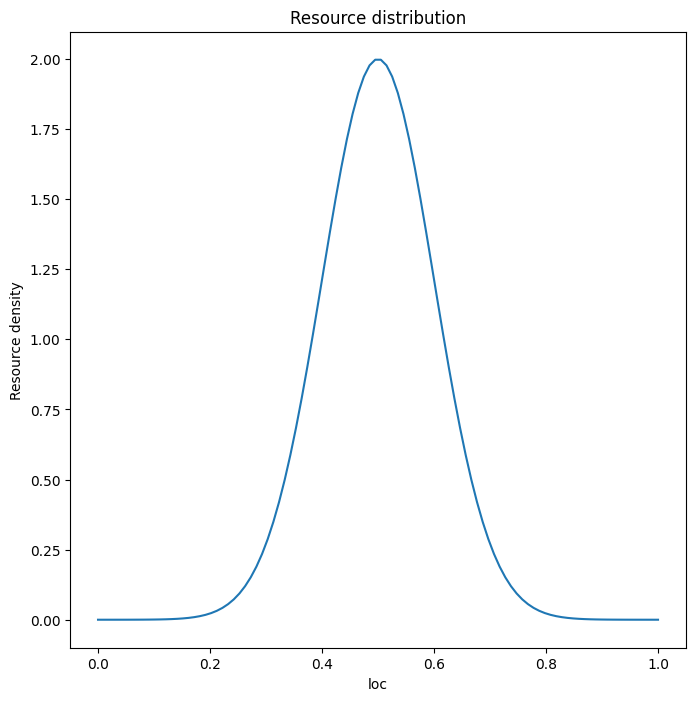

In [3]:
#The resource points
bin_points=np.linspace(.0001, 0.9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-.0/2,.5+.0/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.show()


## Resource distribution (Gaussian asym)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian_asym=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian_asym)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [5]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [6]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [7]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [8]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [23]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=4 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([.4,.55,.55,.6]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=.1) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=5000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = infl_configs, learning_rate_type= 'gradient_magnitude', learning_rate= [.001, .0001, 500], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)


In [30]:
resource_distribution_type="multi_modal_gaussian_distribution_1D"
alpha_current=.5
alpha_st=0
alpha_end = 1
varying_parameter_type='mean'
fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]]
num_points=200


resource_parameters,alpha=general.resource_parameter_setup(resource_distribution_type=resource_distribution_type,varying_parameter_type=varying_parameter_type,alpha_st=alpha_st, alpha_end=alpha_end, fixed_parameters_lst=fixed_parameters_lst,alpha_num_points=num_points)


In [31]:
from InflGame.adaptive import eq_class as eqc 
from InflGame.adaptive.bifurcation_analysis import BifurcationEnv
bif_field=BifurcationEnv(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-8, tolerated_agents = None,ignore_zero_infl= True)
bif_field.setup_adaptive_env()
search=eqc.search_env(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-8, tolerated_agents = None,ignore_zero_infl= True)

In [14]:
import hickle as hkl
test_processed=hkl.load('gaussian_bif_4p.hkl')
results1=hkl.load(f'region{1}_gaussian_stats.hkl')
results2=hkl.load(f'region{2}_gaussian_stats.hkl')
results3=hkl.load(f'region{3}_gaussian_stats.hkl')
results4=hkl.load(f'region{38}_gaussian_stats.hkl')

In [58]:
"""
Combined Bifurcation and Equilibrium Analysis Plot
===================================================
Creates a complex figure layout combining bifurcation diagram with equilibrium analysis plots.
Matches the style and format of visualization.py plotting functions.
"""
import matplotlib.patches as mpatches
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from typing import List, Tuple, Dict, Optional
import matplotlib.figure
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, Wedge, Rectangle, FancyBboxPatch
from matplotlib.collections import PolyCollection, PathCollection


# Helper function to transfer axis content
def transfer_axis_artists(source_ax, target_ax):
    """
    Transfer all visual elements from source axis to target axis by recreating them.
    
    Parameters
    ----------
    source_ax : matplotlib.axes.Axes
        Source axis containing elements to transfer
    target_ax : matplotlib.axes.Axes
        Target axis to receive transferred elements
    """
    # Transfer lines by creating new Line2D objects
    for line in source_ax.get_lines():
        target_ax.plot(line.get_xdata(), line.get_ydata(), 
                      color=line.get_color(),
                      linestyle=line.get_linestyle(),
                      linewidth=line.get_linewidth(),
                      marker=line.get_marker(),
                      markersize=line.get_markersize(),
                      label=line.get_label() if not line.get_label().startswith('_') else '')
    
    # Transfer collections (fill_between creates PolyCollection, including hatched regions)
    for coll in source_ax.collections:
        if isinstance(coll, PolyCollection):
            # Recreate PolyCollection using vertices from paths
            verts = [path.vertices for path in coll.get_paths()]
            new_coll = PolyCollection(verts,
                                     facecolors=coll.get_facecolors(),
                                     edgecolors=coll.get_edgecolors(),
                                     linewidths=coll.get_linewidths(),
                                     linestyles=coll.get_linestyle(),
                                     alpha=coll.get_alpha())
            
            # Transfer hatch pattern if present (for bifurcation region fills)
            if coll.get_hatch():
                new_coll.set_hatch(coll.get_hatch())
            
            # Transfer zorder to maintain layering
            new_coll.set_zorder(coll.get_zorder())
            
            target_ax.add_collection(new_coll)
        elif isinstance(coll, PathCollection):
            # For scatter plots
            offsets = coll.get_offsets()
            if len(offsets) > 0:
                target_ax.scatter(offsets[:, 0], offsets[:, 1],
                                c=coll.get_facecolors(),
                                s=coll.get_sizes(),
                                alpha=coll.get_alpha())
    
    # Transfer patches (pie wedges, bars, etc.) by recreating them
    for patch in source_ax.patches:
        if isinstance(patch, Wedge):
            # Pie chart wedges
            new_wedge = Wedge(patch.center, patch.r, 
                            patch.theta1, patch.theta2,
                            width=patch.width,
                            facecolor=patch.get_facecolor(),
                            edgecolor=patch.get_edgecolor(),
                            linewidth=patch.get_linewidth())
            target_ax.add_patch(new_wedge)
        elif isinstance(patch, Rectangle):
            # Bar charts and other rectangles
            new_rect = Rectangle(patch.get_xy(), patch.get_width(), patch.get_height(),
                               facecolor=patch.get_facecolor(),
                               edgecolor=patch.get_edgecolor(),
                               linewidth=patch.get_linewidth())
            # Transfer hatch if present
            if patch.get_hatch():
                new_rect.set_hatch(patch.get_hatch())
            target_ax.add_patch(new_rect)
        elif isinstance(patch, Polygon):
            # General polygons (may include hatched regions)
            new_poly = Polygon(patch.get_xy(),
                             facecolor=patch.get_facecolor(),
                             edgecolor=patch.get_edgecolor(),
                             linewidth=patch.get_linewidth())
            # Transfer hatch if present
            if patch.get_hatch():
                new_poly.set_hatch(patch.get_hatch())
            target_ax.add_patch(new_poly)
    
    # Transfer text elements by recreating them
    for text in source_ax.texts:
        target_ax.text(text.get_position()[0], text.get_position()[1],
                      text.get_text(),
                      fontsize=text.get_fontsize(),
                      ha=text.get_ha(),
                      va=text.get_va(),
                      color=text.get_color(),
                      transform=target_ax.transData if text.get_transform() == source_ax.transData else text.get_transform())
    
    # Transfer properties
    target_ax.set_xlabel(source_ax.get_xlabel(), fontsize=source_ax.xaxis.label.get_fontsize())
    target_ax.set_ylabel(source_ax.get_ylabel(), fontsize=source_ax.yaxis.label.get_fontsize())
    target_ax.set_title(source_ax.get_title(), fontsize=source_ax.title.get_fontsize())
    
    # Transfer tick labels and positions
    target_ax.set_xticks(source_ax.get_xticks())
    target_ax.set_yticks(source_ax.get_yticks())
    target_ax.set_xticklabels(source_ax.get_xticklabels(), 
                             rotation=source_ax.xaxis.get_ticklabels()[0].get_rotation() if source_ax.xaxis.get_ticklabels() else 0)
    target_ax.set_yticklabels(source_ax.get_yticklabels())
    
    # Check if this is a pie chart (has wedge patches) and remove axis box/ticks
    has_wedges = any(isinstance(patch, Wedge) for patch in source_ax.patches)
    if has_wedges:
        target_ax.set_frame_on(False)
        target_ax.set_xticks([])
        target_ax.set_yticks([])
        target_ax.set_xlabel('')
        target_ax.set_ylabel('')
    
    # Transfer legend with special handling for custom patches
    if source_ax.get_legend():
        source_legend = source_ax.get_legend()
        
        # Get all legend handles - this includes custom patches
        try:
            # Try the correct attribute name first
            legend_handles = source_legend.legend_handles
        except AttributeError:
            # Fallback to legendHandles if needed (older matplotlib versions)
            try:
                legend_handles = source_legend.legendHandles
            except AttributeError:
                # Final fallback: get from get_legend_handles_labels
                legend_handles, _ = source_ax.get_legend_handles_labels()
        
        # Get legend labels
        legend_labels = [text.get_text() for text in source_legend.get_texts()]
        
        # Recreate legend handles to ensure they're properly independent
        new_handles = []
        for handle in legend_handles:
            if isinstance(handle, mpatches.Patch):
                # Recreate patch with same properties including hatch
                new_patch = mpatches.Patch(
                    facecolor=handle.get_facecolor(),
                    edgecolor=handle.get_edgecolor(),
                    linewidth=handle.get_linewidth(),
                    linestyle=handle.get_linestyle(),
                    alpha=handle.get_alpha(),
                    hatch=handle.get_hatch(),  # Include hatch pattern
                    label=handle.get_label()
                )
                new_handles.append(new_patch)
            elif isinstance(handle, Line2D):
                # Recreate line with same properties
                new_line = Line2D([], [],
                                 color=handle.get_color(),
                                 linestyle=handle.get_linestyle(),
                                 linewidth=handle.get_linewidth(),
                                 marker=handle.get_marker(),
                                 markersize=handle.get_markersize(),
                                 label=handle.get_label())
                new_handles.append(new_line)
            else:
                # For other handle types, try to use as-is
                new_handles.append(handle)
        
        # Create the legend with recreated handles
        target_ax.legend(handles=new_handles, labels=legend_labels, 
                        fontsize=source_legend._fontsize,
                        loc=source_legend._loc)
    
    # Transfer aspect (for pie charts and special cases)
    # Skip aspect transfer for bifurcation plots to prevent y-limit distortion in GridSpec
    if source_ax.get_aspect() != 'auto' and has_wedges:
        target_ax.set_aspect(source_ax.get_aspect())
    
    # Set limits AFTER aspect to ensure they're preserved
    target_ax.set_xlim(source_ax.get_xlim())
    target_ax.set_ylim(source_ax.get_ylim())


def transfer_multi_subplot_figure(source_fig, target_ax, label: Optional[str] = None):
    """
    Transfer content from a multi-subplot figure to a single target axis.
    
    Parameters
    ----------
    source_fig : matplotlib.figure.Figure
        Source figure containing subplots to transfer
    target_ax : matplotlib.axes.Axes
        Target axis to receive transferred content
    label : str, optional
        Label to add in upper right corner (e.g., 'a', 'b', 'c', 'd')
    """
    # Get all axes from the source figure
    source_axes = source_fig.get_axes()
    
    if len(source_axes) == 0:
        return
    
    # If there's only one axis, use the simple transfer
    if len(source_axes) == 1:
        transfer_axis_artists(source_axes[0], target_ax)
        return
    
    # For multiple axes, we need to combine them into a single axis
    # Calculate the bounding box for the target axis
    target_bbox = target_ax.get_position()
    
    # Calculate subplot layout within the target axis
    n_subplots = len(source_axes)
    
    # Determine grid layout (horizontal for now)
    cols = n_subplots
    rows = 1
    
    # Create sub-axes within the target axis
    target_ax.set_visible(False)  # Hide the main target axis
    target_ax.set_frame_on(False)
    target_ax.set_xticks([])
    target_ax.set_yticks([])
    
    # Create new axes within the same position as target_ax
    fig = target_ax.figure
    left = target_bbox.x0
    bottom = target_bbox.y0
    width = target_bbox.width / cols
    height = target_bbox.height
    
    # Add spacing between subplots (adjust width factor and add horizontal offset)
    spacing = 0.02  # Space between pie chart and bar chart
    for i, source_ax in enumerate(source_axes):
        # Create a new axis at the appropriate position with spacing
        if i == 0:
            # First subplot (pie chart) - slightly narrower
            new_ax = fig.add_axes([left + i * width, bottom, width * 0.95, height])
        else:
            # Second subplot (bar chart) - add spacing and adjust width
            new_ax = fig.add_axes([left + i * width + spacing, bottom, width * 0.95, height])
        transfer_axis_artists(source_ax, new_ax)
    
    # Add label if provided
    if label is not None:
        # Add text box in upper right corner of the target bbox area
        # Calculate position in figure coordinates
        label_x = target_bbox.x0 + target_bbox.width - 0.38
        label_y = target_bbox.y0 + target_bbox.height - 0.01
        
        # Add a background box
        box = FancyBboxPatch((label_x, label_y), 0.007, 0.007,
                            boxstyle="round,pad=0.005",
                            edgecolor='black',
                            facecolor='white',
                            linewidth=1,
                            transform=fig.transFigure,
                            zorder=1000)
        fig.patches.append(box)
        
        # Add text
        fig.text(label_x + 0.0035, label_y + 0.0035, label,
                ha='center', va='center',
                fontsize=28, fontweight='bold',
                transform=fig.transFigure,
                zorder=1001)


# =============================================================================
# Main Figure Generation
# =============================================================================



def generate_combined_figure(figsize: Tuple[float, float] = (32, 22),
                             width_ratios: List[float] = [1, 1],
                             height_ratios: List[float] = [1, 1, 1],
                             hspace: float = 0.4,
                             wspace: float = 0.12,
                             region_labels: List[str] = ['a', 'b', 'c', 'd'],
                             save: bool = False,
                             save_types: List[str] = ['.png', '.svg'],
                             paper_figure: dict = {'paper': True, 'section': '3_2_6', 'figure_id': 'fig6_combined'},
                             font: dict =  {'default_size': 32, 'cbar_size': 16, 'title_size': 40, 'legend_size': 12, 'font_family': 'sans-serif'}):
    """
    Generate the combined bifurcation and equilibrium analysis figure.
    """
    font['font.family'] = font.get('font_family', 'sans-serif')
    default_font_size = font.get('default_size', 12)
    legend_font_size = font.get('legend_size', 12)
    mpl.rcParams.update({'font.size': default_font_size, 'font.family': font['font.family']})
    mpl.rcParams['legend.fontsize'] = legend_font_size
    # Create the complex layout with GridSpec
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 2, figure=fig, width_ratios=width_ratios, height_ratios=height_ratios, 
                hspace=hspace, wspace=wspace)

    # Main plot spans first 2 rows on the left
    ax_main_new = fig.add_subplot(gs[:2, 0])
    ax4_new = fig.add_subplot(gs[2, 0])  # Bottom left

    # Right column plots
    ax1_new = fig.add_subplot(gs[0, 1])
    ax2_new = fig.add_subplot(gs[1, 1])
    ax3_new = fig.add_subplot(gs[2, 1])

    # Generate main bifurcation plot and transfer to ax_main_new
    fig_temp, ax_temp = bif_field.first_order_bifurcation_plot(
        alpha_st=0,
        alpha_end=alpha[-1],
        processed_data=test_processed,
        alpha_values=alpha,
        save=False,
        font=font,
        paper_figure={'paper': paper_figure['paper'], 'section': paper_figure['section'], 
                    'figure_id': f"{paper_figure.get('figure_id', 'bifurcation_equilibrium_combined')}_main"}
    )
    transfer_axis_artists(ax_temp, ax_main_new)
    plt.close(fig_temp)

    # Add labeled boxes to main bifurcation plot
    main_bbox = ax_main_new.get_position()
    # Center x position and vertical spacing for 4 labels
    y_start = main_bbox.y0 + main_bbox.height * 0.7
    if num_agents==4:
        center_x = [main_bbox.x0 + main_bbox.width / 2 - 0.0075]*3+[main_bbox.x0 + main_bbox.width / 2 +0.11]
        y_spacing = [0, main_bbox.height * 0.15, main_bbox.height * 0.41, main_bbox.height * 0.12]
    else:
        center_x = [main_bbox.x0 + main_bbox.width / 2 - 0.0075]*4
        y_spacing = [0, main_bbox.height * 0.15, main_bbox.height * 0.30, main_bbox.height * 0.55]
    for idx, label in enumerate(region_labels):
        label_y = y_start - y_spacing[idx]
        label_x =center_x[idx]
        
        # Add background box
        box = FancyBboxPatch((label_x, label_y), 0.007, 0.007,
                            boxstyle="round,pad=0.005",
                            edgecolor='black',
                            facecolor='white',
                            linewidth=1,
                            transform=fig.transFigure,
                            zorder=1000)
        fig.patches.append(box)
        
        # Add text
        fig.text(label_x + 0.0035, label_y + 0.0035, label,
                ha='center', va='center',
                fontsize=28, fontweight='bold',
                transform=fig.transFigure,
                zorder=1001)

    # Generate region plots and transfer to respective axes
    results_dicts = [results1, results2, results3, results4]
    target_axes = [ax1_new, ax2_new, ax3_new, ax4_new]

    for idx, (results_dict, target_ax, label) in enumerate(zip(results_dicts, target_axes, region_labels)):
        fig_temp, axes_temp = search.plot_equilibrium_analysis(
            results_dict=results_dict,
            plot_types=['convergence', 'distribution'],
            save=False,
            font={'default_size': 20, 'title_size': 27, 'label_size': 14, 'tick_size': 12, 'legend_size': 12},
            paper_figure={'paper': paper_figure['paper'], 'section': paper_figure['section'], 
                        'figure_id': f"{paper_figure.get('figure_id', 'bifurcation_equilibrium_combined')}_region{idx+1}"},
            name_ads=[f'region{idx+1}']
        )
        transfer_multi_subplot_figure(fig_temp, target_ax, label=label)
        plt.close(fig_temp)

    plt.tight_layout()

    # Save if requested (matching visualization.py pattern)
    if save:
        from InflGame.utils import data_management
        file_names = data_management.data_final_name(
            {'data_type': 'plot', "plot_type": 'bifurcation_equilibrium_combined', 
            'domain_type': '1d', 'num_agents': 4, 
            'section': paper_figure['section'], 
            'figure_id': paper_figure.get('figure_id', 'bifurcation_equilibrium_combined')},
            name_ads=[], save_types=save_types, paper_figure=paper_figure['paper']
        )
        for file_name in file_names:
            fig.savefig(file_name, bbox_inches='tight')

    plt.show()


C:\Users\Mark-Fu-Lab\AppData\Local\Temp\ipykernel_49132\1394175859.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


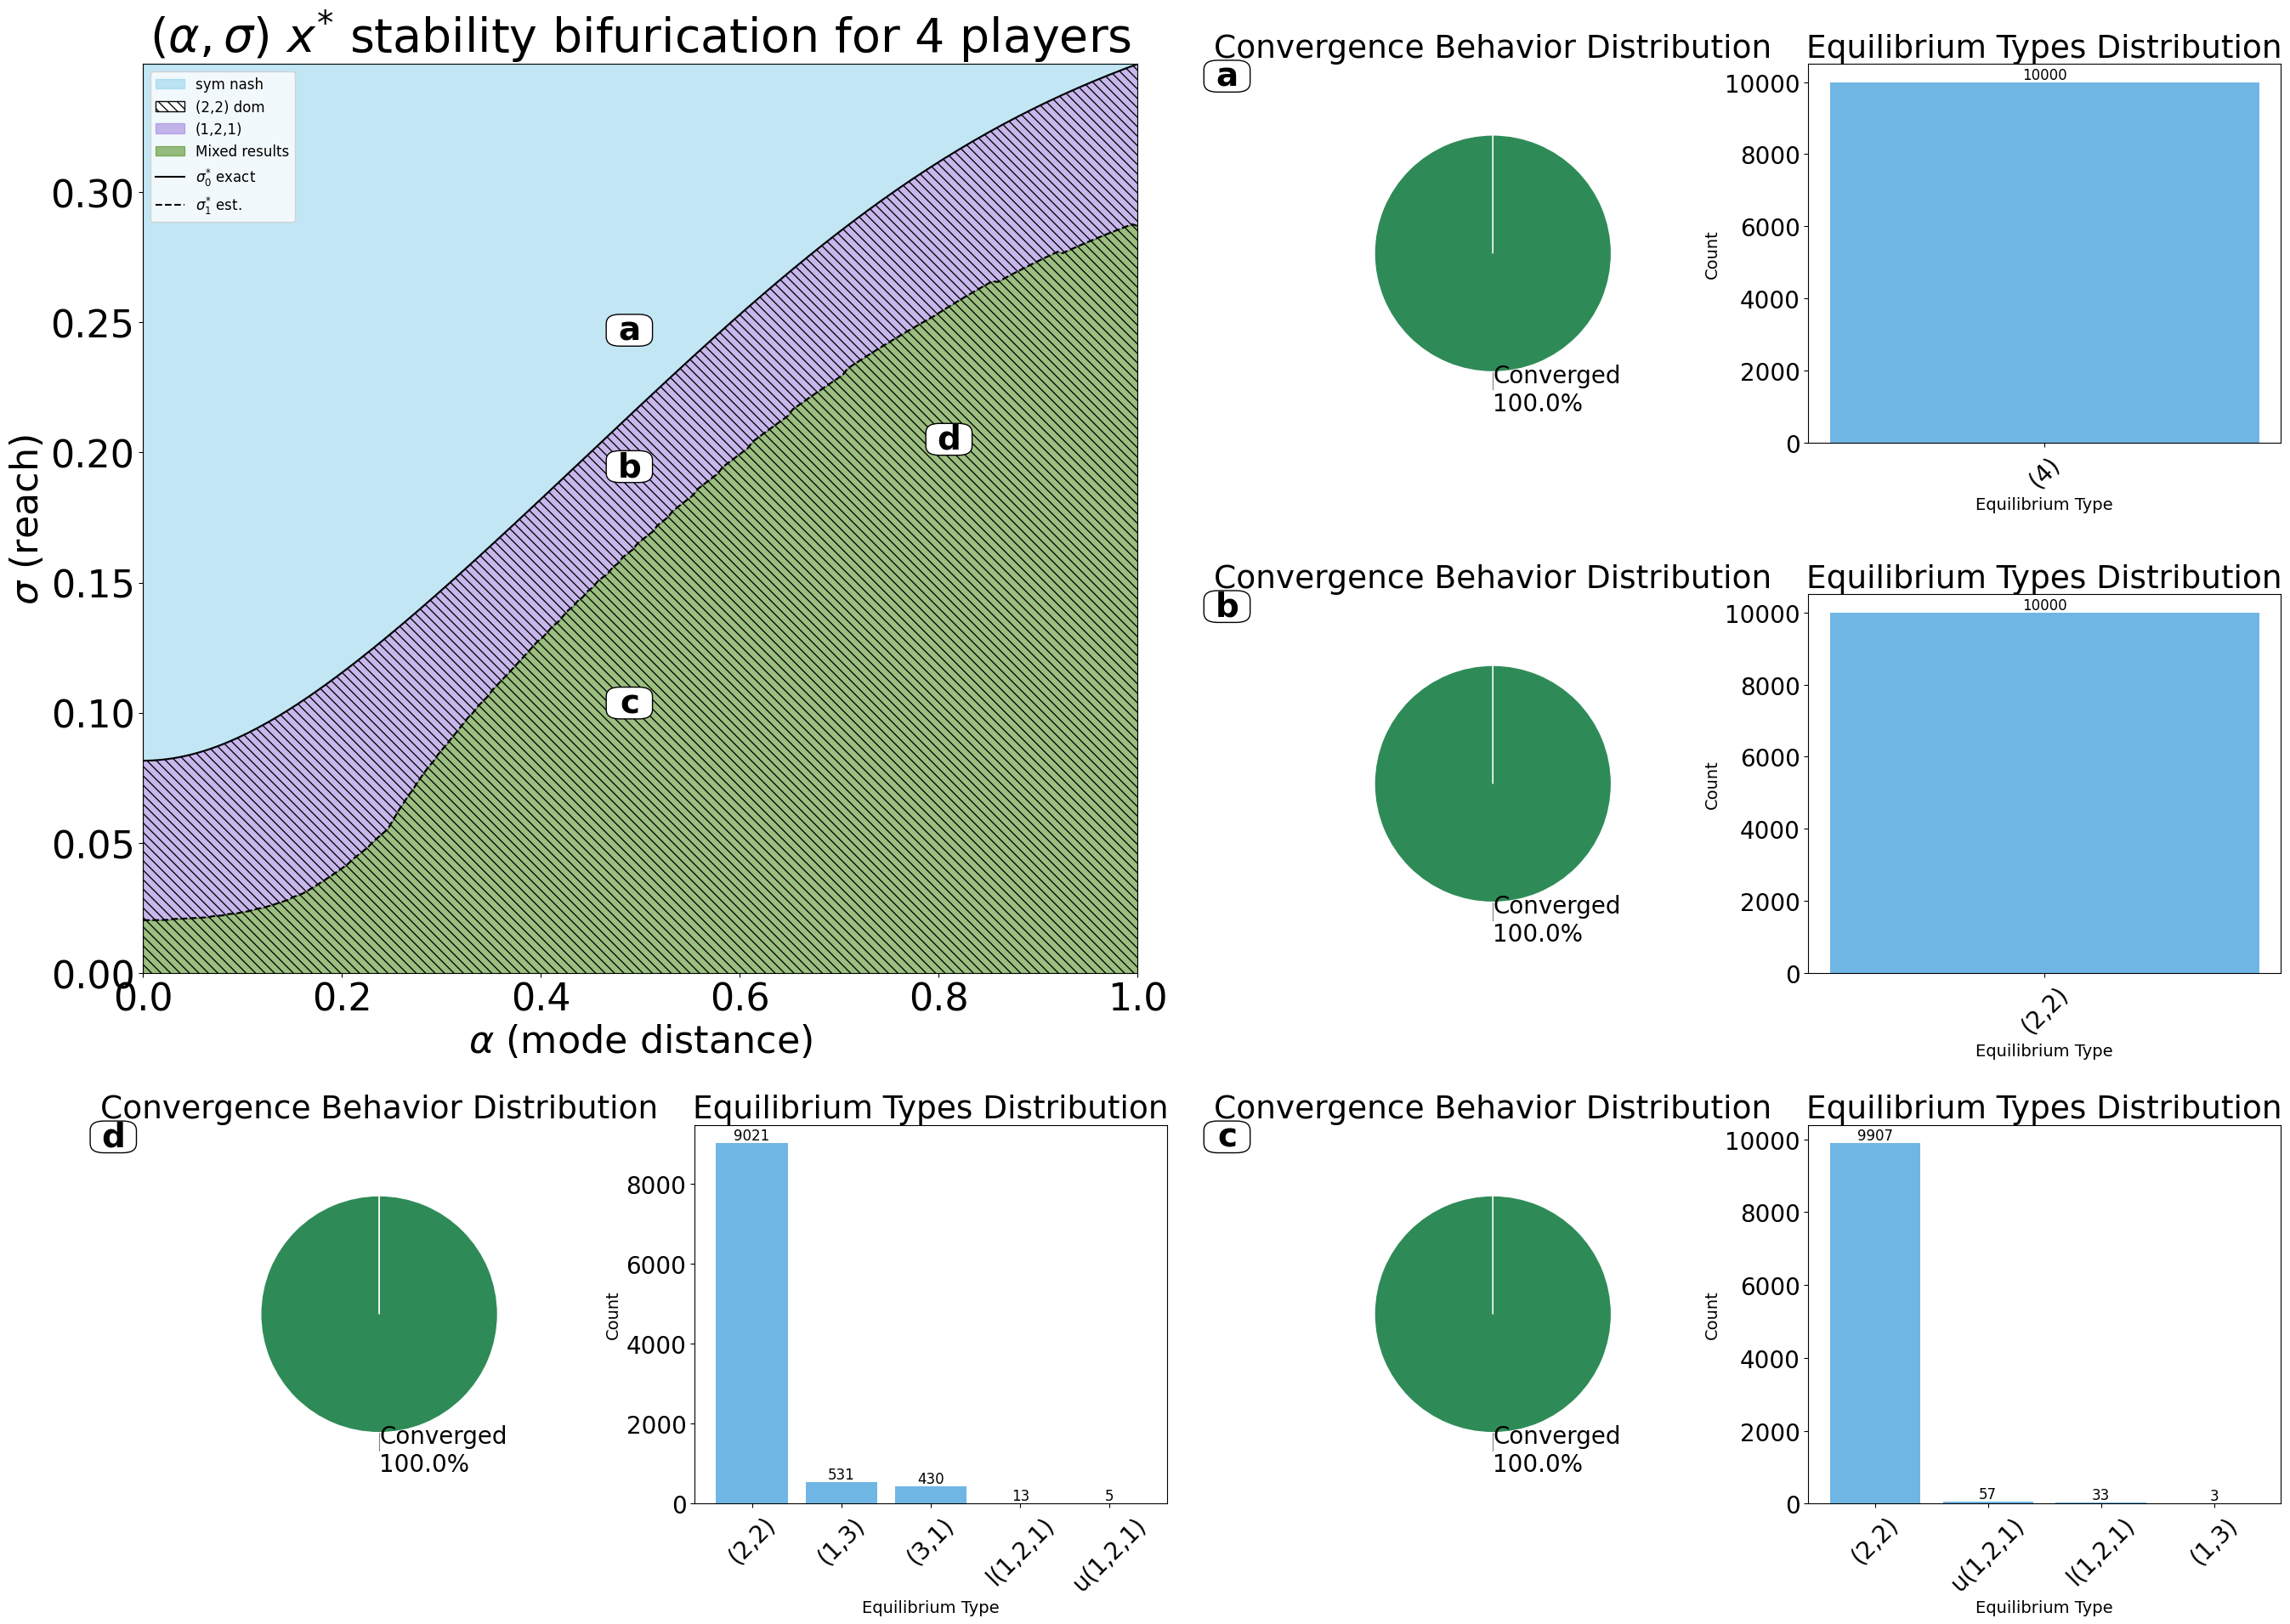

In [59]:
generate_combined_figure(save=True,paper_figure={'paper':True,'section':'3_1_3','figure_id':'fig3p_combined'})